<a href="https://colab.research.google.com/github/enrico-s01/My-Git/blob/main/project_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Do FOMC Statements Influence Regime Switching in Bitcoin Markets?

In [ ]:

%pip install -q requests beautifulsoup4 pandas numpy scikit-learn matplotlib
%pip install hmmlearn
%pip install python-binance


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.4/136.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 37.5 MB/s eta 0:00:00


# Introduction

Central bank communications have a well documented influence on traditional financial markets. Investors closely scrutinize the tone of statements and speeches by central bankers for clues about future policy stance. A large literature finds that a more hawkish or dovish tone can move asset prices and volatility. For example, a more optimistic (dovish) tone in FOMC communications has been shown to raise stock returns, especially during periods of high policy uncertainty. Market participants analyze even subtle wording changes in Fed statements because of their significant signaling power about future policy. In short, what central banks say (and how they say it) materially affects equities, bonds, and other assets in the traditional markets.

This paper asks whether those effects carry over to Bitcoin and the cryptocurrency market. Bitcoin is a decentralized asset often touted as independent from central bank control, yet as it has matured it has shown sensitivity to macroeconomic news and liquidity conditions. Notably, recent studies indicate that Bitcoin does react to U.S. monetary policy surprises: a 1 basis-point unexpected Fed tightening can cause about a 0.25% drop in Bitcoin’s price on the FOMC announcement day (comparable to the reaction of gold), with larger cumulative declines in the days following the meeting as shown in Ma C, Tian Y, Hsiao S, Deng L. Monetary policy shocks and Bitcoin prices. Research in International Business and Finance, 2022. This suggests Fed communications and actions might influence crypto markets much like conventional assets. We therefore investigate whether the tone of Federal Reserve communications, specifically the hawkishness or dovishness of FOMC statements, has any measurable impact on Bitcoin’s regime dynamics. Since the aforementioned papers already show that a more hawkish tone is associated with negative asset returns, we shift the focus from returns to regimes and investigate whether FOMC communication affects the change points in Bitcoin’s price dynamics, i.e. the transitions between low- and high-volatility states.


To explore these questions, we first identify regimes in Bitcoin’s price behavior using a Hidden Markov Model (HMM). HMMs have been widely applied to cryptocurrencies to detect latent market states. Prior work using Markov-switching models on Bitcoin has revealed distinct high-volatility vs. low-volatility regimes and periods of speculative “bubbles” followed by corrections.

Following this literature, we fit a two-state HMM to daily Bitcoin price data (from Binance) to classify each day into a distinct regime. Rather than focusing only on price levels or returns, our interest lies in regime changes – the transitions when Bitcoin shifts from one state to another. We convert these regime transition events into a discrete-time hazard rate, defined as the probability that the regime will switch on a given day conditional on the regime having persisted until that day. We then model this hazard as a function of various covariates using a generalized linear model (GLM) with a complementary log-log (cloglog) link (a standard approach for discrete hazard models). This regime hazard model is a novel approach in the crypto context: it allows us to quantify how external factors affect the risk of a regime ending on any day, analogous to an event risk in survival analysis.

We include several key covariates in the hazard regression, with a special focus on the tone of Fed communication. The primary covariate is our FOMC tone index a custom measure of the hawkishness vs. dovishness in the language of Federal Reserve communications. To construct this, we draw on the dictionary-based sentiment methodology of Apel and Blix Grimaldi (2012), who measured central bank “hawkishness” by counting phrases like “higher inflation” vs. “downside risks.” We use an updated version of their approach tailored to FOMC statements. In particular, we compile a lexicon of hawkish terms (optimism about the economy) and dovish terms (pessimism). We preprocess each FOMC statement (77 post-meeting statements in our sample) by tokenizing the text and applying stemming so that, for example, “inflation” and “inflationary” are treated uniformly. We then count the occurrences of hawkish and dovish words in the text. The tone index is defined as the normalized difference in frequencies of positive (hawkish) vs. negative (dovish) words, divided by total: hawkish words + dovish words. This index ranges from –1 to +1, with positive values indicating an overall hawkish tone and negative values indicating a dovish tone. By construction it captures the net tilt of the FOMC’s language each meeting. Notably, our approach extends prior dictionaries by incorporating modern text-processing to better handle word variants and context, thereby providing a finely tuned hawkishness measure for each Fed statement.

In the hazard model, alongside the FOMC tone index, we control for other factors that might drive Bitcoin regime shifts. These include traditional market risk proxies and crypto-specific variables. We use the CBOE VIX index as a gauge of overall risk aversion and equity market volatility, and the Economic Policy Uncertainty (EPU) index by Baker, Bloom, and Davis as a measure of broader U.S. macro-policy uncertainty. Both high VIX and spikes in policy uncertainty could plausibly trigger shifts in Bitcoin’s regime (e.g. as investors flee risk assets or react to macro news). By including these controls, we ensure that any effect of Fed tone is identified above and beyond the general market turbulence.
The HMM estimation is implemented via the hmmlearn library in Python, and the hazard GLM is estimated using statsmodels with heteroskedasticity-autocorrelation consistent (HAC) standard errors for robust inference. The HAC standard errors address the time-series nature of the hazard data, allowing for serial correlation in regime persistence this gives us more reliable confidence intervals and hypothesis tests rather than assuming i.i.d. errors.

We can summarise our contribution along four main dimensions. First, on the methodological side, we propose a new way to analyse regime changes in Bitcoin: instead of treating regime switches informally, we convert the latent transitions from a two-state HMM into a discrete hazard and model it with a complementary log–log GLM, bringing survival-analysis tools into the study of crypto market regimes. Second, we construct a bespoke FOMC hawkishness index for textual communications, building on the dictionary-based approach of Apel and Blix-Grimaldi (2012) and its later extensions and enriching it with systematic stemming, tokenisation and proximity-based matching, which yields a more precise measure of Fed tone than generic sentiment lexicons. Third, we bridge two strands of literature by asking whether central bank communication tone, known to affect traditional asset markets, also helps to explain regime shifts in Bitcoin once we control for volatility, policy uncertainty and crypto-specific factors. Finally, we pay particular attention to inference in a time-series setting by using HAC-robust standard errors in the hazard GLM, so that our conclusions about the role of FOMC tone are less exposed to spurious significance driven by autocorrelation or heteroskedasticity in the regime-change process.

In preview of our findings, we do not uncover a strong effect of Fed tone on Bitcoin’s regime changes.  This suggests that, the Fed’s rhetorical stance alone has little incremental power to trigger regime shifts in Bitcoin. The crypto market’s transitions between two states seem more attributable to other factors than to nuances of central bank language, a finding that contributes to the ongoing debate on how intertwined crypto is with traditional macro-financial forces. Moving forward, the rest of the paper details our data and methodology and presents the model estimation results.

# Data set overiew

In [ ]:
import re
from typing import List, Optional

import numpy as np
import pandas as pd
import requests
import seaborn as sns

from bs4 import BeautifulSoup
import datetime as time
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem.snowball import SnowballStemmer
from nltk import download as nltk_download
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, brier_score_loss
from sklearn.metrics import confusion_matrix, classification_report
from scipy import stats


## **FOMC Statement Data Collection and Preprocessing**
With FomcUtils we obtain and prepare FOMC statements for subsequent analysis. The get_fomc_urls method scrapes the Federal Reserve’s website to collect all statement URLs, while the feature_extraction method takes a corpus of downloaded documents and returns a pd.DataFrame with one speech per row, its cleaned text, and useful information for the analysis such as release date and time.

In [ ]:

class FomcUtils:
    """Utilities for processing FOMC data."""

    regexp = re.compile(r"\s+", re.UNICODE)

    @staticmethod
    def get_fomc_urls(
        from_year: int = 1999, switch_year: Optional[int] = None
    ) -> List[str]:
        if switch_year is None:
            from datetime import datetime
            switch_year = datetime.now().year - 5

        calendar_url = "https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm"
        r = requests.get(calendar_url)
        soup = BeautifulSoup(r.text, "html.parser")
        contents = soup.find_all(
            "a", href=re.compile("^/newsevents/pressreleases/monetary\\d{8}[ax]\\.htm")
        )
        urls_ = [content.attrs["href"] for content in contents]

        for year in range(from_year, switch_year):
            fomc_yearly_url = f"https://www.federalreserve.gov/monetarypolicy/fomchistorical{year}.htm"
            r_year = requests.get(fomc_yearly_url)
            soup_yearly = BeautifulSoup(r_year.text, "html.parser")
            yearly_contents = soup_yearly.findAll("a", text="Statement")
            for yearly_content in yearly_contents:
                urls_.append(yearly_content.attrs["href"])

        urls = ["https://www.federalreserve.gov" + url for url in urls_]
        return urls

    @staticmethod
    def feature_extraction(
        corpus: List, sent_filters: Optional[List[str]] = None
    ) -> pd.DataFrame:

        '''Extract features from FOMC statements (Hard cut before the publication date (MM/DD/YYYY) + essential cleaning).'''

        if sent_filters is None:
            sent_filters = [
                "Board of Governors",
                "Federal Reserve System",
                "20th Street and Constitution Avenue N.W., Washington, DC 20551",
                "Federal Reserve Board - Federal Reserve issues FOMC statement",
                "Federal Reserve Board - FOMC statement",
                "For immediate release",
                "For release at",
                "DO NOT REMOVE:  Wireless Generation",
                "For media inquiries",
                "or call 202-452-2955.",
                "Last Update",
                "Last update",
            ]

        records = []
        months = r"(January|February|March|April|May|June|July|August|September|October|November|December)"



        '''We remove all noisy webpage elements to cleanly isolate the actual FOMC statement text.
        This ensures that the text analysis is applied only to the relevant informational content.'''

        # Gate pattern: remove everything BEFORE the line "Month, DD, YYYY Federal Reserve issues FOMC statement".

        gate_pat = re.compile(
            rf"^.*?{months}\s+\d{{1,2}},\s+\d{{4}}\s+Federal\s+Reserve\s+issues\s+FOMC\s+statement",
            re.S | re.I,
        )

        title_pat = re.compile(
            r"^\s*Federal\s+Reserve\s+issues\s+FOMC\s+statement(?:\s+Share)?\s*",
            re.I,
        )

        boilerplate_block = re.compile(
            r"An official website.*?Please enable JavaScript.*?(?:below\.)?",
            re.I | re.S,
        )
          # Fallback: typical first setnences of the FOMC statements
        body_start_pats = [
            r"\bInformation received since\b",
            r"\bConsistent with its statutory mandate\b",
            r"\bIn view of realized and expected\b",
            r"\bThe Committee\b",
        ]

        for c in corpus:

            lines = [s for s in c if isinstance(s, str) and s.strip()]

            release_line = next((s for s in lines if "Release Date:" in s), None)
            if release_line is not None:
                date_str = release_line.replace("Release Date:", "").strip()
                release_date = pd.to_datetime(date_str, errors="coerce")
            else:
                release_date = pd.NaT

            lu_candidates = [s for s in lines if "last update" in s.lower()]
            if lu_candidates:
                lu_str = lu_candidates[0].replace("Last update:", "").replace("Last Update:", "").strip()
                last_update = pd.to_datetime(lu_str, errors="coerce")
            else:
                last_update = pd.NaT

            voting = " ".join([s for s in lines if "Voting" in s])
            release_time = " ".join(
                [s for s in lines if ("For release at" in s) or ("For immediate release" in s)]
            )

            # Extract the statement body: keep only lines that are not metadata
            body_lines = []
            for s in lines:
                if s == release_line:
                    continue
                if any(q in s for q in sent_filters):
                    continue
                body_lines.append(FomcUtils.regexp.sub(" ", s))

            text = " ".join(body_lines).strip()


            text = gate_pat.sub("", text).strip()
            text = title_pat.sub("", text).strip()


            if text[:200].lower().startswith(
                ("here's how you know", "an official website", "official websites use .gov")
            ):
                m = None
                for pat in body_start_pats:
                    m = re.search(pat, text, flags=re.I)
                    if m:
                        text = text[m.start():].strip()
                        break


            text = boilerplate_block.sub(" ", text).strip()

            records.append(
                {
                    "release_date": release_date,
                    "last_update": last_update,
                    "text": text,
                    "voting": voting,
                    "release_time": release_time,
                }
            )

        return pd.DataFrame(records)



Download FOMC pages and build the raw text corpus

In [ ]:
def download_fomc_corpus(from_year: int = 1999):

   # Downloads the FOMC webpages starting from from_year and builds the corpus as a list of lists of text lines.

    urls = FomcUtils.get_fomc_urls(from_year=from_year)
    corpus = []

    for url in urls:
        r = requests.get(url)
        r.encoding = "utf-8"
        soup = BeautifulSoup(r.text, "html.parser")

        full_text = soup.get_text("\n")

        lines = [line.strip() for line in full_text.splitlines() if line.strip()]

        corpus.append(lines)

    return urls, corpus

urls, corpus = download_fomc_corpus(from_year=2017)
#len(urls), len(corpus)


/tmp/ipython-input-1769433778.py:26: DeprecationWarning: Call to deprecated method findAll. (Replaced by find_all) -- Deprecated since version 4.0.0.
  yearly_contents = soup_yearly.findAll("a", text="Statement")


Build an FOMC statements DataFrame with cleaned text and reliable dates, extracting dates from the URL when needed; then drop unused information and sort by date.

In [ ]:
fomc_df = FomcUtils.feature_extraction(corpus)
fomc_df["url"] = urls

# Extract data from the URL
def date_from_url(url: str):
    m = re.search(r"(\d{8})", url)
    if m:
        return pd.to_datetime(m.group(1), format="%Y%m%d")
    else:
        return pd.NaT

fomc_df["url_date"] = fomc_df["url"].apply(date_from_url)

fomc_df["release_date"] = fomc_df["release_date"].fillna(fomc_df["url_date"])

# drop unused informations
fomc_df = fomc_df.drop(columns=["url_date", "last_update", "voting"])

# metto release_date come indice e ordino
fomc_df = fomc_df.set_index("release_date").sort_index()

fomc_df.head()

,text,release_time,url
release_date,,,
2017-02-01,Share Information received since the Federal O...,For release at 2:00 p.m. EST,https://www.federalreserve.gov/newsevents/pres...
2017-03-15,Share Information received since the Federal O...,For release at 2:00 p.m. EDT,https://www.federalreserve.gov/newsevents/pres...
2017-05-03,Share Information received since the Federal O...,For release at 2:00 p.m. EDT,https://www.federalreserve.gov/newsevents/pres...
2017-06-14,Share Information received since the Federal O...,For release at 2:00 p.m. EDT,https://www.federalreserve.gov/newsevents/pres...
2017-07-26,Share Information received since the Federal O...,For release at 2:00 p.m. EDT,https://www.federalreserve.gov/newsevents/pres...


In [ ]:

# #data extraction parameter
# import pandas as pd
# import time
# from binance.client import Client
# from datetime import datetime

# # Replace these with your Binance API keys (or use empty strings for public data)
# api_key = ''
# api_secret = ''
# client = Client(api_key, api_secret)

# # Parameters
# symbol = "BTCUSDT"
# interval = Client.KLINE_INTERVAL_1HOUR
# start_date = "1 Jan 2017"
# end_date = "1 June 2025"

# # Fetch historical klines (5min interval)
# print("Fetching data...")
# klines = client.get_historical_klines(symbol, interval, start_str=start_date, end_str=end_date)

# # Convert to DataFrame
# columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume',
#            'close_time', 'quote_asset_volume', 'num_trades',
#            'taker_buy_base_vol', 'taker_buy_quote_vol', 'ignore']
# df = pd.DataFrame(klines, columns=columns)

# # Format timestamps
# df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
# df['close_time'] = pd.to_datetime(df['close_time'], unit='ms')
# df = df.drop(columns=['ignore'])

# #Save to CSV
# filename = f"BTCUSDT_1hour_{start_date.replace(' ', '')}_to_{end_date.replace(' ', '')}.csv"
# df.to_csv(filename, index=False)
# print(f"Saved to {filename}")

We obtain Bitcoin price data from Binance via its public API, using the BTCUSDT pair (Bitcoin quoted in Tether, a stablecoin pegged to the US dollar). This choice ensures that prices are effectively expressed in USD terms. A key limitation of this dataset is its time coverage: since Binance was launched in 2017, we do not observe Bitcoin prices before that date, which excludes the very early phase of Bitcoin’s history.

In practice, downloading the data directly from the Binance API inside Google Colab proved occasionally unstable (API timeouts, environment resets). To ensure reproducibility and faster execution, we downloaded the full BTCUSDT history once, saved it as a CSV file on GitHub, and then accessed that static file in our code. This guarantees that all analyses are based on a fixed, documented dataset.

From the raw OHLCV data (Open, High, Low, Close, Volume), we construct a daily return series. Specifically, for each day t, we compute the (gross) daily return as
$$ R_t = \frac{P_t^{\text{close}}}{P^{\text{open}}_{t}}$$
and work mainly with log returns in the modeling stage. Using open-to-close returns is natural for daily frequency and avoids look-ahead bias (we do not use the next day’s data when characterizing day t).


In [ ]:

url = "https://raw.githubusercontent.com/Gerva02/machine-learning-for-portfolio-managment/refs/heads/main/BTCUSDT_1day_1Jan2017_to_1June2025.csv"
df_bitcoin = pd.read_csv(url)

In [ ]:

df_bitcoin["log_ret_io"] = np.log(df_bitcoin["close"] / df_bitcoin["open"])   # intraday (close/open)
df_bitcoin["log_ret_cc"] = np.log(df_bitcoin["close"]).diff() # or close-to-close:

df_bitcoin['timestamp'] = pd.to_datetime(df_bitcoin['timestamp'], errors='coerce')
df_bitcoin = df_bitcoin[df_bitcoin['timestamp']< "2025-11-11"]
df_bitcoin.head()

,timestamp,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol,log_ret_io,log_ret_cc
0,2017-08-17,4261.48,4485.39,4200.74,4285.08,795.150377,2017-08-17 23:59:59.999,3.454770e+06,3427,616.248541,2.678216e+06,0.005523,NaN
1,2017-08-18,4285.08,4371.52,3938.77,4108.37,1199.888264,2017-08-18 23:59:59.999,5.086958e+06,5233,972.868710,4.129123e+06,-0.042113,-0.042113
2,2017-08-19,4108.37,4184.69,3850.00,4139.98,381.309763,2017-08-19 23:59:59.999,1.549484e+06,2153,274.336042,1.118002e+06,0.007665,0.007665
3,2017-08-20,4120.98,4211.08,4032.62,4086.29,467.083022,2017-08-20 23:59:59.999,1.930364e+06,2321,376.795947,1.557401e+06,-0.008454,-0.013053
4,2017-08-21,4069.13,4119.62,3911.79,4016.00,691.743060,2017-08-21 23:59:59.999,2.797232e+06,3972,557.356107,2.255663e+06,-0.013143,-0.017351


We use the U.S. Daily Economic Policy Uncertainty (EPU) index provided by Baker, Bloom and Davis, downloaded from their official website (policyuncertainty.com). The EPU index is constructed from newspaper coverage of terms related to the economy, policy, and uncertainty; the daily version aggregates news signals to provide a high-frequency proxy of policy-related uncertainty in financial markets. It is widely used in the macro-finance literature as a measure of “policy risk”.

We again mirror the original CSV to GitHub and load it from there in the notebook to avoid network issues and to fix the exact version of the dataset used. We trim the EPU series to match the time span of our Bitcoin sample (from Binance launch in 2017 onwards) and merge by date. In our model, the EPU index serves as a control variable for broad macroeconomic and policy risk: spikes in EPU often coincide with political standoffs, trade disputes, or fiscal uncertainty, all of which can affect risk assets. By including EPU, we reduce the risk of attributing Bitcoin regime shifts to FOMC tone when they may instead be driven by general policy uncertainty.


In [ ]:

url_uncertanty = "https://raw.githubusercontent.com/Gerva02/machine-learning-for-portfolio-managment/refs/heads/main/All_Daily_Policy_Data.csv"
df_unc= pd.read_csv(url_uncertanty)
df_unc['dates'] = pd.to_datetime(df_unc[['year','month','day']])
df_unc  = df_unc.drop(columns=["day","month","year"])
df_unc = df_unc[df_unc['dates']> "2017-08-16"]
df_unc.head()

,daily_policy_index,dates
11916,56.82,2017-08-17
11917,60.34,2017-08-18
11918,121.57,2017-08-19
11919,89.23,2017-08-20
11920,60.63,2017-08-21


For global market risk, we employ the VIX index, obtained from the Chicago Board Options Exchange (CBOE) historical data. The VIX measures the 30-day implied volatility of the S&P 500 and is a standard gauge of equity market fear. Unlike Bitcoin, S&P 500 options trade only on business days and during market hours, so the VIX is not defined on weekends and overnight gaps.

Because Bitcoin trades 7 days a week whereas the EPU index is not always reported for non-business days, we handle missing observations using a forward fill: when a day has a missing EPU value, we assign it the last available value, implemented as fillna(method='ffill') in pandas. Another modeling choice is that we use the VIX at the market open (or previous close) rather than a contemporaneous post-close value. This ensures we do not inadvertently use information about same-day equity moves that would only be known after the Bitcoin daily open, thereby avoiding a timing inconsistency where the VIX could “see” the day’s volatility that we are trying to explain in Bitcoin.

The VIX is a natural control for our setting: if global risk aversion surges (e.g., during a stock market crash), we expect many risky assets—including Bitcoin—to become more volatile. By controlling for VIX, we can better isolate whether FOMC communication tone has any additional explanatory power for Bitcoin volatility regime changes beyond what is already captured by general market stress.


In [ ]:
url_vix = "https://raw.githubusercontent.com/Gerva02/machine-learning-for-portfolio-managment/refs/heads/main/VIX_History.csv"
df_vix = pd.read_csv(url_vix)
df_vix  = df_vix.astype({"DATE" : "datetime64[ns]"}).rename(columns={'DATE': 'dates'})
df_vix = df_vix[df_vix['dates']> "2017-08-16"]
df_vix.head()

,dates,OPEN,HIGH,LOW,CLOSE
6959,2017-08-17,11.81,15.77,11.54,15.55
6960,2017-08-18,15.38,16.04,13.32,14.26
6961,2017-08-21,14.59,14.74,13.07,13.19
6962,2017-08-22,12.60,12.94,11.35,11.35
6963,2017-08-23,11.51,12.59,11.39,12.25


## Descriptive statistics

We then pass to the descriptive statistics part for the biticoin time series by doin an histogram of past returns

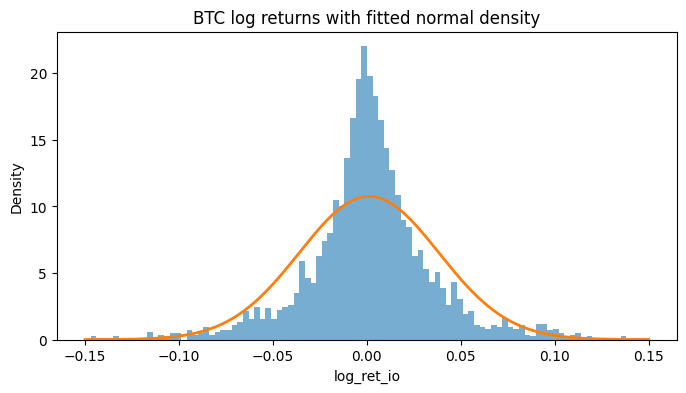

In [ ]:

window = 0.15
plt.figure(figsize=(8,4))
count, bins, patches = plt.hist(
    df_bitcoin["log_ret_io"],
    bins=100,
    range=(-window, window),
    density=True,
    alpha=0.6,
    edgecolor='none'
)

#Fit normal: mean and std of your data
mu =df_bitcoin["log_ret_io"].mean()
sigma = df_bitcoin["log_ret_io"].std()

# x-grid and Gaussian pdf
x = np.linspace(-window, window, 500)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-(x - mu)**2 / (2 * sigma**2))

plt.plot(x, pdf, linewidth=2)  # overlaid normal density

plt.title("BTC log returns with fitted normal density")
plt.xlabel("log_ret_io")
plt.ylabel("Density")
plt.show()

Even though it might resemble a normal distribution, we can clearly see  that there are heavy tails .To validate this result we do a jacque-bera test

In [ ]:

stats.jarque_bera(df_bitcoin["log_ret_io"])

SignificanceResult(statistic=np.float64(27003.801347005923), pvalue=np.float64(0.0))

The Jarque Bera test strongly rejects the null hypothesis $H_0$ that
the **unconditional** distribution of Bitcoin returns is normal. This is
not a problem for our Gaussian HMM, because the model assumes **conditional
normality**:
$$
r_t \mid S_t = k \sim \mathcal{N}(\mu_k, \sigma_k^2),
$$

i.e. returns are normal *given* the latent volatility regime $S_t$. The
unconditional distribution is a mixture of these regime-specific normals
and is not expected to be normal  (since the mixture of two normal is not normal as long as they do not have the same distribution), so rejection of unconditional normality
is actually consistent with a regime-switching structure.


Here we can see that there are many observations that satisfy the condition  
$$\left|\log\left(\frac{P_t^{\text{close}}}{P_t^{\text{open}}}\right)\right| > 0.15.
$$

For example, if  
$$
\log\left(\frac{P_t^{\text{close}}}{P_t^{\text{open}}}\right) = 0.15,
\implies
\frac{P_t^{\text{close}}}{P_t^{\text{open}}} = e^{0.15} \approx 1.16,
$$
which corresponds to about a **16% price increase** in a single day.

Similarly, if  
$$\log\left(\frac{P_t^{\text{close}}}{P_t^{\text{open}}}\right) = -0.15,\implies
\frac{P_t^{\text{close}}}{P_t^{\text{open}}} = e^{-0.15} \approx 0.86, $$
which corresponds to about a **14% price drop** in a single day.

Therefore, the filter  
$$
\left|\log\left(\frac{P_t^{\text{close}}}{P_t^{\text{open}}}\right)\right| > 0.15
$$
selects days where Bitcoin experiences very large moves (around **15% or more in absolute value**). This highlights how frequent extreme daily price swings are in the Bitcoin market.

In [ ]:
df_bitcoin[df_bitcoin["log_ret_io"].abs() > 0.15 ]

,timestamp,open,high,low,close,volume,close_time,quote_asset_volume,num_trades,taker_buy_base_vol,taker_buy_quote_vol,log_ret_io,log_ret_cc
28,2017-09-14,3944.00,3993.00,3165.13,3189.02,1665.021543,2017-09-14 23:59:59.999,5.914261e+06,9066,761.153976,2.711572e+06,-0.212482,-0.212657
112,2017-12-07,13541.01,16649.96,13050.00,16599.00,7487.065695,2017-12-07 23:59:59.999,1.095553e+08,57541,3931.041376,5.750146e+07,0.203620,0.202952
127,2017-12-22,15514.03,15699.34,10961.00,13326.61,36076.271175,2017-12-22 23:59:59.999,4.775099e+08,243261,17556.682449,2.334353e+08,-0.151982,-0.150602
152,2018-01-16,13500.00,13542.93,9035.00,10900.00,63401.169175,2018-01-16 23:59:59.999,7.221508e+08,418243,30353.401717,3.467771e+08,-0.213927,-0.216880
172,2018-02-05,8179.99,8382.80,6625.00,6939.99,63403.182579,2018-02-05 23:59:59.999,4.711662e+08,533510,29857.358390,2.220224e+08,-0.164391,-0.164980
593,2019-04-02,4144.54,4897.99,4140.54,4857.29,105383.639263,2019-04-02 23:59:59.999,4.890187e+08,609133,55726.141684,2.583008e+08,0.158689,0.158684
799,2019-10-25,7412.41,8799.00,7361.00,8655.02,90748.218174,2019-10-25 23:59:59.999,7.373295e+08,775418,49588.976612,4.027403e+08,0.154984,0.154984
938,2020-03-12,7934.58,7966.17,4410.00,4800.00,261505.608653,2020-03-12 23:59:59.999,1.628590e+09,1770812,119298.006197,7.434817e+08,-0.502615,-0.502607
939,2020-03-13,4800.01,5955.00,3782.13,5578.60,402201.673764,2020-03-13 23:59:59.999,2.063820e+09,2309830,197511.954273,1.017424e+09,0.150320,0.150322
1271,2021-02-08,38795.69,46794.45,37988.89,46374.87,138597.536914,2021-02-08 23:59:59.999,5.881537e+09,3230961,72345.891568,3.069314e+09,0.178449,0.178449


We then proced to standardize the result to have more stable numerical solution for the HMM step.

In [ ]:
desc_ret = df_bitcoin["log_ret_io"].describe()
skew_ret = df_bitcoin["log_ret_io"].skew()
kurt_ret = df_bitcoin["log_ret_io"].kurtosis()

print("bitcoin log return descriptive stats:\n")
print(desc_ret)
print("\nSkew:", skew_ret)
print("Kurtosis:", kurt_ret)

bitcoin log return descriptive stats:

count    2846.000000
mean        0.001136
std         0.037143
min        -0.502615
25%        -0.014130
50%         0.000864
75%         0.016759
max         0.203620
Name: log_ret_io, dtype: float64

Skew: -0.9625209817310437
Kurtosis: 14.995675880531428


The distribution of Bitcoin daily log returns is clearly non Gaussian. The mean
return is close to zero and the median is slightly positive, but the skewness of
about −0.96 indicates a mild **left asymmetry**: large negative moves are more
pronounced than large positive ones. The most striking feature is the kurtosis
of roughly 15, which is far above the value of 3 for a normal distribution. This
strong **leptokurtosis** reflects very heavy tails and a high frequency of
extreme observations, consistent
with what we saw in the histogram and the extreme outliers in the time-series
plot. These fat tails justify departing from simple Gaussian assumptions and
motivate the use of regime-switching models that can better accommodate clusters
of unusually high volatility.

In [ ]:
prova = df_bitcoin["log_ret_io"].dropna().values.reshape(-1,1)
stdreturn = (prova - prova.mean())/ prova.std()

We now analyze the descriptive statistics for the VIX

In [ ]:
# @title
df_vix.head()

,dates,OPEN,HIGH,LOW,CLOSE
6959,2017-08-17,11.81,15.77,11.54,15.55
6960,2017-08-18,15.38,16.04,13.32,14.26
6961,2017-08-21,14.59,14.74,13.07,13.19
6962,2017-08-22,12.60,12.94,11.35,11.35
6963,2017-08-23,11.51,12.59,11.39,12.25


The mean level is about 19.5with a standard deviation of 7.6, and the interquartile range from roughly
14.4 to 22.5 indicates that typical trading days feature relatively low
implied volatility. However, the maximum value of 82.7, together with a
skewness above 2.5 and kurtosis above 12, reveals a very long right tail: a
small set of crisis days exhibit extremely high VIX readings. Thus, like EPU,
the VIX mostly reflects calm conditions but occasionally records very large
jumps, providing a useful control for rare episodes of global risk-off behaviour in our hazard model.


In [ ]:
# Make sure index is sorted by date
df_vix = df_vix.sort_index()

# Use VIX at market open
vix = df_vix['OPEN']

# Descriptive statistics
desc_vix = vix.describe()
skew_vix = vix.skew()
kurt_vix = vix.kurtosis()

print("VIX (OPEN) descriptive stats:\n")
print(desc_vix)
print("\nSkew:", skew_vix)
print("Kurtosis:", kurt_vix)

VIX (OPEN) descriptive stats:

count    2097.000000
mean       19.536309
std         7.629796
min         9.010000
25%        14.430000
50%        17.690000
75%        22.520000
max        82.690000
Name: OPEN, dtype: float64

Skew: 2.5494106629690734
Kurtosis: 12.06265400124473


From this time–series plot we can see that the VIX at the open exhibits sharp spikes
during well–known periods of market turmoil (e.g. the COVID-19 shock). The absence of negative values and the
location of the spikes exactly where we would expect them provide a simple
sanity check on the data quality: the series behaves as a standard measure of
equity market fear and captures periods of heightened risk in a plausible way.

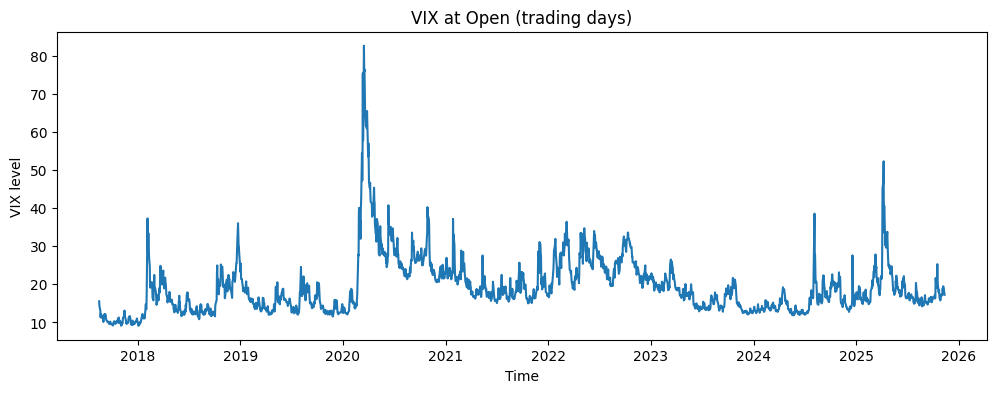

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(df_vix["dates"], df_vix['CLOSE'] )
plt.title('VIX at Open (trading days)')
plt.ylabel('VIX level')
plt.xlabel('Time')
plt.show()

Exactly as we expect the fix doesn't have a normal distribution but it is more similar to a  $\chi^2$ distirbution.

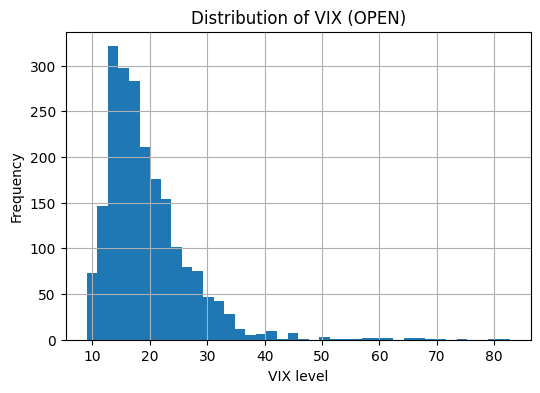

In [ ]:
plt.figure(figsize=(6, 4))
vix.hist(bins=40)
plt.title('Distribution of VIX (OPEN)')
plt.xlabel('VIX level')
plt.ylabel('Frequency')
plt.show()

The EPU index has an average level of about 172 with a very large standard
deviation of 137, confirming that uncertainty varies substantially over time.
The interquartile range (roughly 83 to 209) suggests that in “normal” periods
the index fluctuates in the low hundreds, whereas the maximum reading above
1,000 corresponds to extreme episodes such as the COVID-19 crisis. The skewness
of about 2 and kurtosis around 4.7 indicate a right-skewed, heavy-tailed
distribution: most of the time uncertainty is moderate, but there is a small
number of very large spikes. This behaviour is desirable for our purposes,
since EPU is meant to capture rare periods of intense policy and macro risk.


In [ ]:
unc = df_unc["daily_policy_index"]

#Descriptive statistics
desc_unc = unc.describe()
skew_unc = unc.skew()
kurt_unc= unc.kurtosis()

print("VIX (OPEN) descriptive stats:\n")
print(desc_unc)
print("\nSkew:", skew_unc)
print("Kurtosis:", kurt_unc)

VIX (OPEN) descriptive stats:

count    3009.000000
mean      171.643111
std       137.365818
min         4.050000
25%        83.310000
50%       124.580000
75%       209.080000
max      1026.380000
Name: daily_policy_index, dtype: float64

Skew: 2.0179491347258303
Kurtosis: 4.720011196361787


The US Daily EPU index shows long stretches of moderate uncertainty punctuated
by sharp spikes. We see a clear jump in early 2020 around the COVID-19 shock,
followed by a gradual decline but still elevated volatility in the index. More
recently, from 2024 onward the series drifts back up with frequent bursts,
suggesting renewed policy and macro uncertainty. Overall, the plot confirms
that EPU behaves as a “crisis indicator”: most days are relatively calm, but
major events generate sudden, short-lived surges in measured uncertainty.


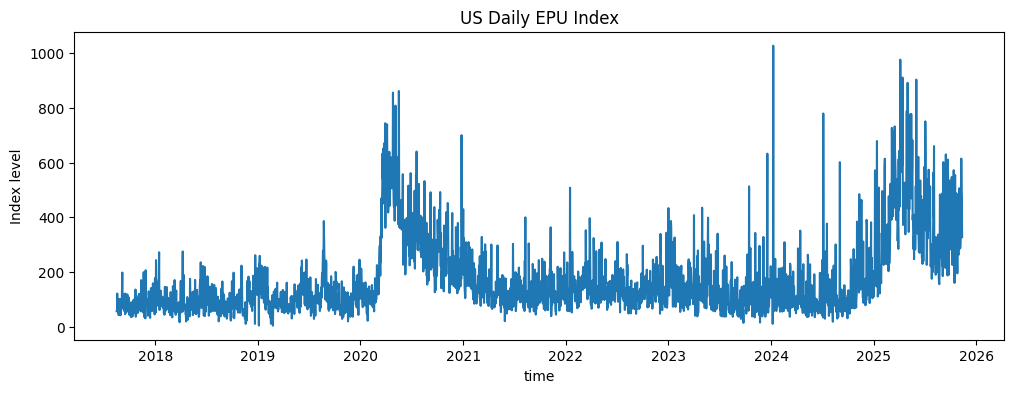

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot( df_unc["dates"], unc)
plt.title('US Daily EPU Index')
plt.ylabel('Index level')
plt.xlabel('time')
plt.show()

# Analytics and learning strategies

## Central Bank Specific Tone Dictionary Construction

In this section, our goal is to construct a dictionary specifically tailored to central bank communication, rather than relying on generic financial dictionaries such as Loughran–McDonald, which are not designed with Fed speeches in mind. Recent work has shown that using central-bank-specific tone dictionaries is important for capturing the informational content of policy communication, for example Hubert and Labondance (2019) on central bank tone and the dispersion of views within monetary policy committees and Hansen, McMahon and Prat (2018) on FOMC deliberation and transparency. Following this literature, we build on the directional word lists developed by Apel and Blix-Grimaldi (2012, *The Information Content of Central Bank Minutes*), originally constructed to measure the tone of central bank minutes and to predict the Riksbank’s future policy decisions, and later translated and extended to other central banks and to the FOMC in Apel, Blix Grimaldi, Hull (2021, *How Much Information Do Monetary Policy Committees Disclose?*). Starting from these resources, we design a custom dictionary for FOMC statements and turn it into a set of robust matching rules based on stemming, tokenisation and proximity-based pattern detection.

Our tone measure is built on a dictionary-based algorithm whose goal is to classify short phrases in FOMC statements as **hawkish** or **dovish** in an economically meaningful way. In the appendix of Apel and Blix-Grimaldi (2012), the authors provide primitive lists of modifiers hawkish or dovish ( “high”, “low”, “increasing”, “decreasing”, “strong”, “weak”) and economic nouns (e.g. “inflation”, “prices”, “wages”, “growth”, “employment”), designed to describe whether macro conditions are moving in a direction consistent with tighter or easier policy. In the first step of our algorithm, we take these base lists of nouns and modifiers and construct all possible **bigrams** of the form “modifier + noun”. Concretely, we form combinations like “high inflation”, “low growth”, “increasing wages”, “weak employment”, which constitute a “base” dictionary of directional economic phrases. At this stage the bigrams are still generic and are only tagged as hawkish or dovish according to what the modifier suggests.

We then expand this base dictionary using the updated framework in Apel, Blix-Grimaldi and Hull (2021, How Much Information Do Monetary Policy Committees Disclose?), which enriches the sets of modifiers and economic terms with a more explicit focus on three key areas: inflation (B1), economic activity (B2) and employment (B3). For each of these blocks we take the extended lists of modifiers and terms suggested in the 2021 paper and again generate all possible “modifier + term” bigrams. Finally, we merge the base dictionary and the updated B1–B3 dictionaries into a single combined lexicon.

To make the dictionary robust to inflected forms and flexible word order in the documents, we then move from raw text to stem based rules. Each modifier and each word in the term are passed through the Snowball stemmer for English: the modifier is reduced to a single stem (e.g. “rising”, “rise”, “rose” → `ris`), and the term is split into tokens and each token is stemmed (e.g. “inflation pressure” → `["inflation", "pressure"]` → `["inflation", "pressur"]`). For each dictionary entry we store the raw modifier and term, their stems, the tone and the topic, thereby obtaining a set of **matching rules** that operate in stem space rather than on surface word forms.

Finally, we define the text preprocessing and matching algorithm that applies these rules to the FOMC corpus. Each statement is cleaned and normalised and splitted into tokens. Each token is then stemmed with the same Snowball stemmer used for the dictionary. Given this stemmed token sequence, we scan for each rule by locating all positions where the modifier stem appears and, around each position, searching within a small **proximity window** for all stemmed term tokens. If all term stems can be found within the window (in any order), we declare that rule as “triggered” in the document. Summing across all hawkish and dovish rules yields document-level counts of hawkish and dovish phrases that reflect the ABG economic classification, but are robust to inflection, punctuation and modest rephrasings thanks to stemming, tokenisation and proximity-based matching (e.g. we can match “inflation is rising rapidly” even if the canonical dictionary form is “rising inflation”).


In [ ]:

# Base Dictionary: adjectives x nouns (ABG 2012)

base_hawkish = ["high", "higher", "strong", "stronger", "increasing", "increased", "fast", "faster"]
base_dovish  = ["low", "lower", "weak", "weaker", "decreasing", "decreased", "slow", "slower"]
base_nouns = [
    "inflation", "price", "prices", "wage", "wages",
    "oil price", "oil prices", "growth", "development",
    "employment", "unemployment", "recovery", "cost", "costs"
]

base_dict = [(f"{adj} {noun}", "hawkish", "base") for adj in base_hawkish for noun in base_nouns]
base_dict += [(f"{adj} {noun}", "dovish", "base") for adj in base_dovish for noun in base_nouns]


# Dictionary ABG updated (2021)
'''They updated the dictionary with a particoluar focus on three areas: Inflation (B1), Economic activity (B2) and Employment (B3).
We derived this extension from the official paper by Apel, Blix-Grimaldi and Hull (2021), “How Much Information Do Monetary Policy
Committees Disclose? Evidence from the FOMC's Minutes and Transcripts”, Appendix B.'''

#Inflation
infl_terms = ["consumer prices", "inflation", "inflation pressure"]
hawk_mods_B1 = [
    "accelerat", "boost", "elevated", "escalat", "high", "increas", "jump", "pickup",
    "rise", "rose", "rising", "run-up", "runup", "strong", "surg", "up", "build", "emerg",
    "great", "height", "intensif", "mount", "stok", "sustain"
]
dove_mods_B1 = [
    "decelerat", "declin", "decreas", "down", "drop", "fall", "fell", "low", "muted", "reduc",
    "slow", "stable", "subdued", "weak", "contained", "abat", "contain", "dampen", "dimin",
    "eas", "moder", "reced", "temper"
]
infl_dict = [(f"{mod} {term}", "hawkish", "inflation") for term in infl_terms for mod in hawk_mods_B1]
infl_dict += [(f"{mod} {term}", "dovish", "inflation") for term in infl_terms for mod in dove_mods_B1]

#Economic activity
activity_terms = ["consumer spending", "economic activity", "economic growth", "resource utilization"]
hawk_mods_B2 = [
    "accelerat", "edg up", "expan", "increas", "pick up", "pickup", "soft", "strength", "strong",
    "weak", "buoyant", "high", "rise", "rose", "rising", "step up", "tight", "upside"
]
dove_mods_B2 = [
    "contract", "decelerat", "decreas", "drop", "retrench", "slow", "slugg", "subdued",
    "curtail", "declin", "downside", "fall", "fell", "low", "moder", "loose"
]
act_dict = [(f"{mod} {term}", "hawkish", "activity") for term in activity_terms for mod in hawk_mods_B2]
act_dict += [(f"{mod} {term}", "dovish", "activity") for term in activity_terms for mod in dove_mods_B2]

#Employment
employment_terms = ["employment", "labor market", "unemployment"]
hawk_mods_B3 = [
    "expand", "gain", "improv", "increas", "pick up", "pickup", "rais", "rise", "rising",
    "rose", "strength", "turn up", "strain", "tight", "declin", "fall", "reduc"
]
dove_mods_B3 = [
    "slow", "declin", "reduc", "weak", "deteriorat", "shrink", "shrank", "fall", "fell", "drop",
    "contract", "sluggish", "eased", "easing", "loos", "soft", "elevat", "high", "increas", "ris", "rose"
]
empl_dict = [(f"{mod} {term}", "hawkish", "employment") for term in employment_terms for mod in hawk_mods_B3]
empl_dict += [(f"{mod} {term}", "dovish", "employment") for term in employment_terms for mod in dove_mods_B3]


# Union and cleaning. Output: cb_dict (bigram, tone, topic)
combined = base_dict + infl_dict + act_dict + empl_dict
cb_dict = pd.DataFrame(combined, columns=["bigram", "tone", "topic"])
cb_dict["bigram"] = cb_dict["bigram"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
cb_dict.drop_duplicates(subset=["bigram", "tone", "topic"], inplace=True)
cb_dict.reset_index(drop=True, inplace=True)


# Construction of robust rules (stemming)
nltk_download('punkt', quiet=True)

stemmer = SnowballStemmer("english")

def split_bigram(bigram: str):
    """
    Split a bigram into (modifier, terms).
    not necessary when we already know how the bigrams were constructed, it makes
    only the subsequent processing more robust to alternative dictionary sources
    """
    parts = bigram.split()
    if len(parts) < 2:
        return parts[0], ""
    return parts[0], " ".join(parts[1:])

dict_rows = []
for _, row in cb_dict.iterrows():
    mod_raw, term_raw = split_bigram(row["bigram"])
    dict_rows.append({
        "mod_raw": mod_raw,
        "term_raw": term_raw,
        "mod_stem": stemmer.stem(mod_raw),
        "term_stems": [stemmer.stem(t) for t in term_raw.split()] if term_raw else [],
        "tone": row["tone"],
        "topic": row["topic"],
    })

df_rules = pd.DataFrame(dict_rows).drop_duplicates(subset=["mod_raw", "term_raw", "tone", "topic"]).reset_index(drop=True)

hawk_rules = df_rules[df_rules["tone"] == "hawkish"].to_dict("records")
dove_rules = df_rules[df_rules["tone"] == "dovish"].to_dict("records")


# Function for tokenisation w/ stemming and matching based on word proximity
def stem_tokens(text: str):

    t = re.sub(r"[-’']", " ", str(text).lower())
    t = re.sub(r"[^a-z0-9.% ]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    toks = t.split()
    return [stemmer.stem(tok) for tok in toks]

def match_rule(stems, rule, window: int = 2) -> int:

    '''Verify if a rule is staisfied in a stemmed document.
    We use a 'window' = maximum allowed distance between modifier adn terms for a match.'''

    if not rule["mod_stem"]:
        return 0
    L = len(stems)
    mod_positions = [i for i, s in enumerate(stems) if s == rule["mod_stem"]]
    if not mod_positions:
        return 0

    term_parts = rule["term_stems"]
    if not term_parts:
        return 0

    for mpos in mod_positions:
        ok = True
        start = max(0, mpos - (window + 2))
        end   = min(L, mpos + (window + 3))
        for part in term_parts:
            found = any(stems[j] == part for j in range(start, end))
            if not found:
                ok = False
                break
        if ok:
            return 1
    return 0


#Constructing and Normalising the FOMC Tone Score

Now our goal is to compute a tone score for each FOMC statement. We do this by counting how many hawkish and dovish rules are triggered in each document using count_hawk_dove_for_doc, and then applying this procedure to all texts with get_tone_counts_proximity. We first compute a net tone index $(\text{hawkish}−\text{dovish})/(\text{hawkish}+\text{dovish})$, which lies between -1 and 1 and captures the relative balance between hawkish and dovish phrases in each statement. We then standardise this series to obtain a z-scored tone measure with mean zero and unit variance, so that values can be interpreted in terms of deviations from the average FOMC tone over our sample. This normalisation makes the tone index directly comparable across time and easier to use as an explanatory variable in regressions and state-dependent models.

In [ ]:

def count_hawk_dove_for_doc(text: str, w: int = 2):
    #Function which gives (hawkish, dovish, haw+dov) for a certain document.
    stems = stem_tokens(text)
    haw = sum(match_rule(stems, r, window=w) for r in hawk_rules)
    dov = sum(match_rule(stems, r, window=w) for r in dove_rules)
    return haw, dov, haw + dov

#To apply on all texts
def get_tone_counts_proximity(text_series: pd.Series, window: int = 2) -> pd.DataFrame:
    counts = text_series.apply(lambda txt: pd.Series(
        count_hawk_dove_for_doc(txt, w=window), index=["hawkish", "dovish", "all"]
    ))
    return counts.astype(int)

X_text = fomc_df["text"]
tone_counts = get_tone_counts_proximity(fomc_df["text"], window=2)


# Construction of the tone score
tone_score = (tone_counts["hawkish"] - tone_counts["dovish"]) / tone_counts["all"].replace(0, np.nan)
tone_score = tone_score.fillna(0.0).rename("tone_score")

tone_score_norm = ((tone_score - tone_score.mean()) / tone_score.std()).fillna(0.0).rename("tone_score_norm")


Costruzione Xt

In [ ]:
Xt_fomc = pd.concat([tone_score, tone_score_norm], axis=1)

# Label
Xt_fomc["tone_label"] = np.where(
    Xt_fomc["tone_score_norm"] > 0, "hawkish",
    np.where(Xt_fomc["tone_score_norm"] < 0, "dovish", "neutral")
)
#release time from fomc_df
Xt_fomc["release_time"] = fomc_df["release_time"]

event_days = Xt_fomc.index.floor("D")

# daily index
daily_index = pd.date_range(
    start=event_days.min(),
    end=event_days.max(),
    freq="D",
)

Xt_daily_by_date = Xt_fomc.copy()
Xt_daily_by_date.index = Xt_daily_by_date.index.floor("D")
Xt_daily_by_date = Xt_daily_by_date.groupby(level=0).last()

# Final hourly DataFrame
Xt_daily = pd.DataFrame(index=daily_index)
Xt_daily["tone_score"] = 0
Xt_daily["tone_score_norm"] = 0
Xt_daily["tone_label"] = 0
Xt_daily["release_time"] = 0
Xt_daily["is_fomc"] = 0

# fill only dates of the FOMC st.
for d in event_days:
    if d in Xt_daily_by_date.index:
        Xt_daily.loc[d, ["tone_score", "tone_score_norm", "tone_label", "release_time"]] = (
            Xt_daily_by_date.loc[d, ["tone_score", "tone_score_norm", "tone_label", "release_time"]].values
        )
        Xt_daily.loc[d, "is_fomc"] = 1
Xt_daily_virgin = Xt_daily.copy()
# Extend the tone score in a window opened around the statement date
pre  = pd.Timedelta("1D")
post = pd.Timedelta("14D")
for d in event_days:
    start_d = (d - pre)
    end_d   = (d + post)
    mask_d = (Xt_daily.index >= start_d) & (Xt_daily.index < end_d)

    Xt_daily.loc[mask_d, "is_fomc"] = 1
    Xt_daily.loc[mask_d, ["tone_score", "tone_score_norm", "tone_label", "release_time"]] = (
        Xt_daily.loc[d, ["tone_score", "tone_score_norm", "tone_label", "release_time"]].values
    )

Xt_daily.head(30)

/tmp/ipython-input-740155979.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.3333333333333333' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xt_daily.loc[d, ["tone_score", "tone_score_norm", "tone_label", "release_time"]] = (
/tmp/ipython-input-740155979.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.252025828475692' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xt_daily.loc[d, ["tone_score", "tone_score_norm", "tone_label", "release_time"]] = (
/tmp/ipython-input-740155979.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'hawkish' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Xt_daily.loc[d, ["to

,tone_score,tone_score_norm,tone_label,release_time,is_fomc
2017-02-01,0.333333,0.252026,hawkish,For release at 2:00 p.m. EST,1
2017-02-02,0.333333,0.252026,hawkish,For release at 2:00 p.m. EST,1
2017-02-03,0.333333,0.252026,hawkish,For release at 2:00 p.m. EST,1
2017-02-04,0.333333,0.252026,hawkish,For release at 2:00 p.m. EST,1
2017-02-05,0.333333,0.252026,hawkish,For release at 2:00 p.m. EST,1
2017-02-06,0.333333,0.252026,hawkish,For release at 2:00 p.m. EST,1
2017-02-07,0.333333,0.252026,hawkish,For release at 2:00 p.m. EST,1
2017-02-08,0.333333,0.252026,hawkish,For release at 2:00 p.m. EST,1
2017-02-09,0.333333,0.252026,hawkish,For release at 2:00 p.m. EST,1
2017-02-10,0.333333,0.252026,hawkish,For release at 2:00 p.m. EST,1


## Hidden Markov Model


A Hidden Markov Model (HMM) provides a convenient way to model returns that
switch between unobserved “regimes.” At each date $t$ there is a latent state
$z_t$ in our case, either a low–volatility regime or a high–volatility
regime  and an observed return $x_t$. The latent states evolve according to a
first–order Markov chain: the probability of tomorrow’s regime depends only on
today’s regime, not the complete past.

The model is defined by three sets of parameters:
1. **Initial state distribution**, which gives the probability of starting in
   each regime.
2. **Transition matrix**, where each row gives the probabilities of moving from
   one regime to the next. The diagonal elements quantify *regime persistence*.
3. **State-dependent (emission) distributions**, which specify how returns are
   distributed conditional on each regime. In our Gaussian HMM, each state has
   its own mean and variance, so the high-volatility regime is characterized by
   a much larger variance than the low-volatility regime.

Given these parameters, the HMM assigns a joint probability to any sequence of
states and returns. Because enumerating all possible state sequences is
infeasible, we rely on dynamic-programming algorithms. The **forward–backward
procedure** computes posterior probabilities $P(z_t = i \mid x_{1:T})$, known
as *smoothed probabilities*, which give the probability of being in each regime
at each time, this again if we weren't doing a retroactive study would be a fatal flaw since it would use information from the future.

In our analysis, however, we use the second standard summary: the **Viterbi
path**. The Viterbi algorithm finds the single most likely sequence of regimes
given the entire sample of returns. This produces a hard classification
$z_t \in \{\text{low vol}, \text{high vol}\}$ for each day.



In [ ]:
from hmmlearn.hmm import GaussianHMM
from scipy import stats

In [ ]:

hmm = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=1000,
    tol=1e-3,
    random_state=0
)
hmm.fit(stdreturn )

GaussianHMM(covariance_type='full', n_components=2, n_iter=1000, random_state=0,
            tol=0.001)

In [ ]:
states = hmm.predict(stdreturn )       #path of the states
post   = hmm.predict_proba(stdreturn )     # smooth posterior probabilities
print("means (scaled):\n", hmm.means_.ravel())
print("vars (scaled):\n", hmm.covars_.ravel())
print("A (transitions):\n", hmm.transmat_)

means (scaled):
 [ 0.00486495 -0.00837706]
vars (scaled):
 [0.22131233 2.34074724]
A (transitions):
 [[0.8150418  0.1849582 ]
 [0.31826149 0.68173851]]


The estimated 2-state Gaussian HMM clearly separates a **low-volatility** and a
**high-volatility** regime. State 0 has a small positive mean return 0.005 and a low variance 0.22, while state 1 has a slightly negative mean 0.008 and a much larger variance 2.34. This justifies interpreting
state 0 as the calm regime and state 1 as the turbulent regime. We also notice that the state of high volatility is way more persistant.


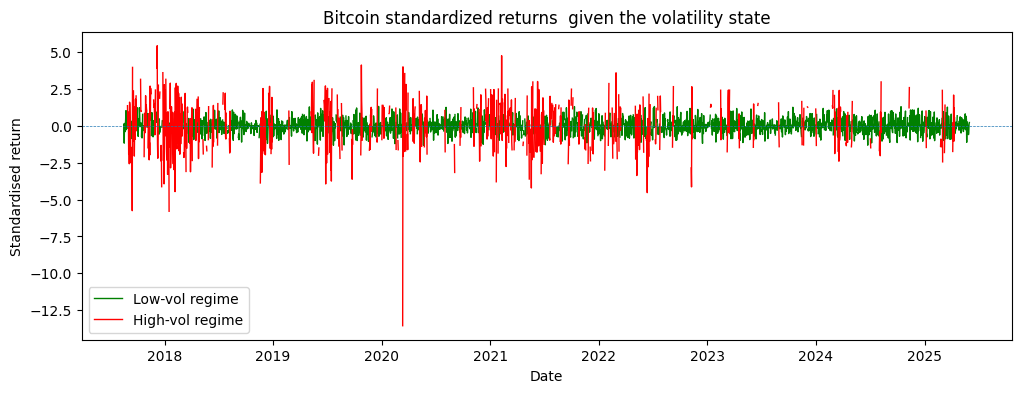

In [ ]:
# build a Series for convenience
stdreturn_1d = np.asarray(stdreturn).squeeze()
ret_series = pd.Series(stdreturn_1d , index=df_bitcoin['timestamp'])

# copy and mask by regime
low_line  = ret_series.copy()
high_line = ret_series.copy()

low_line[states == 1]  = np.nan   # hide high-vol points from low-vol line
high_line[states == 0] = np.nan   # hide low-vol points from high-vol line

plt.figure(figsize=(12,4))
plt.plot(low_line.index,  low_line,  'g-', linewidth=1, label='Low-vol regime')
plt.plot(high_line.index, high_line, 'r-', linewidth=1, label='High-vol regime')
plt.axhline(0, linewidth=0.5, linestyle='--')
plt.title('Bitcoin standardized returns  given the volatility state')
plt.xlabel('Date')
plt.ylabel('Standardised return')
plt.legend()
plt.show()


In [ ]:
Xt_merge = Xt_daily
Xt_merge["dates"] = Xt_daily.index
Xt_merge.head()

,tone_score,tone_score_norm,tone_label,release_time,is_fomc,dates
2017-02-01,0.333333,0.252026,dovish,For release at 2:00 p.m. EST,1,2017-02-01
2017-02-02,0.333333,0.252026,dovish,For release at 2:00 p.m. EST,1,2017-02-02
2017-02-03,0.333333,0.252026,dovish,For release at 2:00 p.m. EST,1,2017-02-03
2017-02-04,0.333333,0.252026,dovish,For release at 2:00 p.m. EST,1,2017-02-04
2017-02-05,0.333333,0.252026,dovish,For release at 2:00 p.m. EST,1,2017-02-05


The variable `onset` marks the **first day of a new high-volatility regime**,
i.e. the moment when the smoothed probability of being in the high-vol state
jumps from clearly low (`p_high ≤ τ_lo`) to clearly high (`p_high ≥ τ_hi`), we impose a buffer so to avoid jitters in the time series. This has also the benefit to be way less serialy correlated than the states them selfes.

In [ ]:
p = pd.Series(post[:, 1], name='p_high')
tau_lo, tau_hi = 0.4, 0.6
onset = (p.shift(1) <= tau_lo) & (p >= tau_hi)
cambio_prob  = (p - p.shift(1)).fillna(0) # we fill the first obs with 0
print(f"The ts changes {round(sum(onset)/len(onset),3)} of the total")

The ts changes 0.051 of the total


In [ ]:
out = pd.DataFrame({
    "onset": onset.astype(int),
    "dates": df_bitcoin["timestamp"],
    "vol" : df_bitcoin["volume"],
    "cambio_prob": cambio_prob
})
out

,onset,dates,vol,cambio_prob
0,0,2017-08-17,795.150377,0.000000
1,0,2017-08-18,1199.888264,0.372604
2,0,2017-08-19,381.309763,-0.247839
3,0,2017-08-20,467.083022,-0.049934
4,0,2017-08-21,691.743060,-0.002500
...,...,...,...,...
2841,0,2025-05-28,15633.788290,0.015232
2842,0,2025-05-29,19834.701160,0.031294
2843,0,2025-05-30,23706.497990,-0.016419
2844,0,2025-05-31,11289.359220,-0.017867


A key limitation of our logistic (hazard) regression is the sparsity of
informative observations. Regime onsets are rare events, and they are even
rarer on FOMC days: only 53 observations in our sample satisfy
`onset = 1` and `is_fomc = 1`. This means that the covariate matrix contains
very little variation in the FOMC-related variables exactly at the times when
the event of interest occurs. As a result, the signal-to-noise ratio is low
and the model has very limited power to detect any effect of the tone index
on regime breaks; estimated coefficients are therefore noisy and imprecise.


In [ ]:
result = pd.merge(out, Xt_merge, on="dates", how="left").merge(df_unc, on="dates", how="left").merge(df_vix, on="dates", how="left").fillna(method='ffill')
result["interaction"] = result["is_fomc"] * result["tone_score_norm"].abs()
result[(result["onset"]==1 )& (result["is_fomc"]==1 )]

/tmp/ipython-input-3032618056.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  result = pd.merge(out, Xt_merge, on="dates", how="left").merge(df_unc, on="dates", how="left").merge(df_vix, on="dates", how="left").fillna(method='ffill')


,onset,dates,vol,cambio_prob,tone_score,tone_score_norm,tone_label,release_time,is_fomc,daily_policy_index,OPEN,HIGH,LOW,CLOSE,interaction
131,1,2017-12-26,15034.668104,0.630159,0.000000,-0.212343,hawkish,For release at 2:00 p.m. EST,1,106.31,10.19,10.46,10.13,10.25,0.212343
228,1,2018-04-02,32123.560072,0.312640,1.000000,1.180763,dovish,For release at 2:00 p.m. EDT,1,167.71,21.07,25.72,20.44,23.62,1.180763
259,1,2018-05-03,38768.388288,0.419489,0.000000,-0.212343,hawkish,For release at 2:00 p.m. EDT,1,57.16,15.78,18.66,15.43,15.90,0.212343
266,1,2018-05-10,25055.063718,0.409368,0.000000,-0.212343,hawkish,For release at 2:00 p.m. EDT,1,74.02,13.36,13.63,12.92,13.23,0.212343
309,1,2018-06-22,52157.370833,0.718268,1.000000,1.180763,dovish,For release at 2:00 p.m. EDT,1,80.35,14.60,14.60,13.11,13.77,1.180763
348,1,2018-07-31,48296.915587,0.628775,1.000000,1.180763,dovish,For release at 2:00 p.m. EDT,1,91.35,13.98,14.12,12.81,12.83,1.180763
352,1,2018-08-04,36288.426010,0.528009,1.000000,1.180763,dovish,For release at 2:00 p.m. EDT,1,107.88,12.43,12.46,11.07,11.64,1.180763
355,1,2018-08-07,45438.473501,0.338463,1.000000,1.180763,dovish,For release at 2:00 p.m. EDT,1,72.24,11.12,11.24,10.52,10.93,1.180763
454,1,2018-11-14,46478.964003,0.751166,1.000000,1.180763,dovish,For release at 2:00 p.m. EST,1,53.94,20.52,22.36,19.30,21.25,1.180763
459,1,2018-11-19,70580.892856,0.705074,1.000000,1.180763,dovish,For release at 2:00 p.m. EST,1,10.92,18.78,20.99,18.52,20.10,1.180763


## Logistic regression



We model the probability of a volatility–regime onset as a **discrete-time hazard**:
$$
h_t = \Pr(\text{onset}_t = 1 \mid \text
 X_t),
$$
estimated using a Generalized Linear Model with a **complementary log–log (cloglog)** link.  
The cloglog link is the canonical choice for discrete-time survival models because
$$
h_t = 1 - \exp\{-\exp(\eta_t)\},\qquad
\eta_t = \beta_0 + \beta^\top X_t,
$$
is a direct discretization of a continuous-time proportional hazards model.

Under this formulation, each coefficient $\beta_k$ has a **hazard-ratio interpretation**:
$$
\exp(\beta_k)
$$
is the multiplicative change in the instantaneous risk of a regime break associated
with a one-unit increase in predictor $X_k$.  
- $\exp(\beta_k) > 1$: the covariate **raises** the hazard  
- $\exp(\beta_k) < 1$: the covariate **reduces** the hazard  
- $\exp(\beta_k) = 1$: no effect

This interpretation aligns directly with classical survival analysis and is much more natural for regime-switching problems than a standard logit model,
because the outcome is inherently a **timing event**.


In addition, we construct a duration variable `days_since_last_onset`, which
counts how many days have elapsed since the previous volatility break. Including
this counter in the covariate vector allows the discrete-time hazard to exhibit
**duration dependence**: the risk of a new regime onset can increase or decrease
as the calm period becomes longer. In other words, the model does not assume a
constant baseline hazard; instead, it lets the probability of a break depend
both on contemporaneous covariates (volume, tone, VIX, etc.) and on the time
spent in the current regime.


In [ ]:
df = result.sort_values('dates').copy()

days_since = 0
duration = []

for flag in df['onset']:
    duration.append(days_since)
    if flag == 1:
        # reset counter when a new volatility break (onset) happens
        days_since = 0
    else:
        days_since += 1

result['days_since_last_onset'] = duration

Before going on to the logistic regression, we check if the data is deeply linearly correlated that would give numerical problems to our estimation.

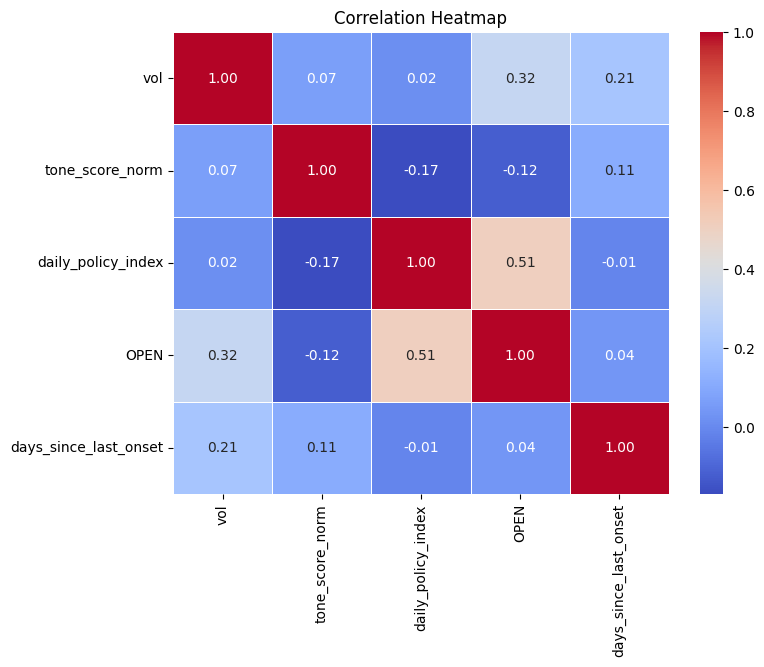

In [ ]:
matrix = result[["vol","tone_score_norm","daily_policy_index","OPEN","days_since_last_onset"]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

We cannot see big collinearities between the regressor so we procede, with the logistic regression.

In [ ]:
import statsmodels.api as sm
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import CLogLog
X = sm.add_constant(result[["vol","tone_score_norm","daily_policy_index","OPEN","days_since_last_onset"]])  # intercept
y = onset

model = sm.GLM(onset, X, family=Binomial(link=CLogLog()))
res = model.fit(cov_type="HAC", cov_kwds={"maxlags":10})
print(res.summary())

# predicted probabilities (P[y=1])
p_hat = res.predict(X)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 p_high   No. Observations:                 2846
Model:                            GLM   Df Residuals:                     2840
Model Family:                Binomial   Df Model:                            5
Link Function:                CLogLog   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -563.88
Date:                Mon, 17 Nov 2025   Deviance:                       1127.8
Time:                        16:44:39   Pearson chi2:                 2.85e+03
No. Iterations:                     6   Pseudo R-squ. (CS):           0.004269
Covariance Type:                  HAC                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -2.87

The dependent variable is the daily probability of a regime onset (low– to
high–volatility switch), modelled with a complementary log–log link so that
coefficients can be interpreted in terms of their effect on the **hazard**
of an onset.

- **Intercept (const = −2.87, p < 0.001).**  
  When all covariates are at their reference level, the linear predictor is
  −2.87. In a cloglog model this corresponds to a baseline daily hazard of
  approximately 5–6% for a regime onset. This is the average risk of a break
  in a “typical” day, before conditioning on volume, tone, etc.

- **Volume (vol = 1.87×10⁻⁶, p = 0.029).**  
  The coefficient is positive and statistically significant. Exponentiating,
  the hazard ratio is `exp(1.87×10⁻⁶) ≈ 1.0000019` per unit of volume. Given
  the scale of the volume variable, this means that days with unusually high
  trading activity are associated with a slightly higher probability of a
  volatility regime break. Economically, this is consistent with the idea that
  turbulence in Bitcoin tends to occur on days of intense trading.

- **FOMC tone (tone_score_norm = −0.423, p = 0.001).**  
  The tone coefficient is negative and statistically significant at conventional
  levels. The corresponding hazard ratio is `exp(−0.423) ≈ 0.66`, implying that
  a one–standard–deviation increase in the tone index reduces the estimated
  hazard of a regime onset by roughly 34%, holding other variables constant.
  However, given the overall very low pseudo R² of the model (≈ 0.004), this
  effect should be interpreted with caution: it is statistically detectable but
  contributes only marginally to explaining regime switches.

- **Policy uncertainty (daily_policy_index = 0.0002, p = 0.745).**  
  This coefficient is small and far from significant. The associated hazard
  ratio is essentially 1, indicating that, in this specification, the daily
  policy uncertainty index does not have a meaningful association with the
  timing of volatility regime breaks once other covariates are included.

- **VIX at the open (OPEN = −0.0157, p = 0.206).**  
  The price level at the open has a mildly negative coefficient but is not
  statistically significant. The implied hazard ratio, `exp(−0.0157) ≈ 0.98`
  per unit, suggests no robust evidence that the vix as any impact on the regime of bitcoin
  
- **Duration (days_since_last_onset = 0.0026, p = 0.474).**  
  This variable measures how long (in days) the system has remained in the
  low–volatility regime. Its coefficient is close to zero and statistically
  insignificant. The hazard ratio `exp(0.0026) ≈ 1.003` indicates that the
  hazard does not systematically increase or decrease with the time spent in
  the calm regime; we do not find evidence of strong duration dependence in
  regime breaks.

Finally, the pseudo R-squared of about 0.004 shows that the model explains
only a very small fraction of the variation in regime onsets. Even though some
coefficients (volume and tone) are statistically significant, the overall
explanatory power of the specification is weak, reinforcing the idea that
volatility regime switches in Bitcoin are largely driven by factors not
captured by our covariates.


# Empirical resuts:


By maximising the F1-score for regime onsets we end up with a very low threshold (~5%), so the model flags many days as onsets, boosting recall but destroying precision and overall accuracy (worse than always predicting “no onset”). In a highly imbalanced time series this shows that F1-based threshold tuning can yield practically useless cutoffs, and since our GLM is a hazard model, the predicted probabilities rather than a single in-sample, unvalidated threshold—are the more meaningful output.
Given the weak performance of this approach, future work could improve the model by selecting the threshold on a separate validation set or via rolling time-series cross-validation, targeting an economically meaningful precision or false-alarm rate rather than maximising F1.

In [ ]:
# 1) pick threshold via F1
prec, rec, th = precision_recall_curve(y, p_hat)
f1 = 2*prec*rec/(prec+rec + 1e-12)
best_idx = int(np.nanargmax(f1))
best_thr = th[max(best_idx-1, 0)]  # precision_recall_curve returns thresholds of length n-1

In [ ]:
# 2) binarize and compute confusion matrix
y_pred = (p_hat >=best_thr).astype(int)
cm = confusion_matrix(y, y_pred)
print("Threshold (F1-max):", round(float(best_thr), 4))
print("Confusion matrix [[TN FP],[FN TP]]:\n", cm)
print()
print(classification_report(y, y_pred, digits=3))

Threshold (F1-max): 0.052
Confusion matrix [[TN FP],[FN TP]]:
 [[1955  747]
 [  79   65]]

              precision    recall  f1-score   support

       False      0.961     0.724     0.826      2702
        True      0.080     0.451     0.136       144

    accuracy                          0.710      2846
   macro avg      0.521     0.587     0.481      2846
weighted avg      0.917     0.710     0.791      2846



In [ ]:
# 3) rare-event friendly metrics
prauc = average_precision_score(y, p_hat)
brier = brier_score_loss(y, p_hat)
base = y.mean()
brier_skill = 1 - brier/(base*(1-base))
print(f"PR-AUC: {prauc} | Brier: {brier} | Base rate: {base} | Brier skill: {brier_skill}")


PR-AUC: 0.07263303863155549 | Brier: 0.04781705277661119 | Base rate: 0.050597329585382995 | Brier skill: 0.0045836740080340554


## Data Partitioning Strategy

This study does not use a traditional train/validation/test split because it is not a predictive task, but rather a retrospective analysis designed to test whether macroeconomic tone (from FOMC speeches) has explanatory power for regime shifts in Bitcoin volatility. The question is not “can we predict?” but “did tone ever matter?”, thus our goal is causal inference and signal detection, not forecasting.

We estimate the model on the full dataset because the goal of the analysis is
retrospective and explanatory rather than predictive. In particular, even the
response variable of the hazard model (the regime–onset indicator) is derived
from the smoothed state probabilities of the HMM, which themselves are computed
using the entire sample. This means that the latent state sequence is estimated
with knowledge of future observations. While this would be inappropriate for a
real-time forecasting exercise, it is entirely consistent with our objective:
we aim to understand, *ex post*, whether FOMC tone is associated with regime
transitions, not to build a deployable prediction engine.

Because our interest lies in uncovering historical correlates of volatility
breaks rather than generating out of sample forecasts, we do not implement a
train/test split. The model is estimated once on the complete set of historical
episodes, analogous to fitting a survival or hazard model to the full life
history of a subject. Coefficients are therefore interpreted as conditional
associations within this retrospective framework, with no claim of
out of sample predictive validity.

Moreover, there is little risk of overfitting. The model performs poorly even in sample, as seen from the low pseudo R-squared  0.004 and modest z-scores for most coefficients. In fact, it is best described as **underfit** too simple or too data-starved to capture meaningful structure. This is a null result analysis: we test whether FOMC tone moves the needle on regime onsets, and the answer is no. That conclusion holds without needing a holdout set.


# Conclusion

In summary, this project conducted an empirical analysis to investigate whether historical FOMC communication tone coincided with shifts in Bitcoin volatility regimes. Using a two-step approach, first identifying volatility states with a Markov-switching model, then explaining regime transition events with a hazard regression, we do not find strong or robust evidence that our text-based measure of Fed tone helps to explain when Bitcoin switches from a low- to a high-volatility regime. Our analytical narrative was framed as an ex post explanation rather than a pure prediction exercise: instead of asking “Can Fed tone predict Bitcoin crashes?”, we asked “Did major Bitcoin volatility episodes align with Fed tone changes after the fact?”. Within this framework, the answer from our data and model is largely negative. Even when some coefficients on the tone variable are statistically significant, the corresponding classification performance is weak and does not materially outperform simple benchmarks.

This retrospective study contributes to the growing literature on how (or if) traditional macro-financial signals interact with cryptocurrencies. While central bank actions and communications are known to move interest rates, equities and even gold, our specific regime switching plus hazard framework suggests that Bitcoin’s volatility regimes are not strongly or systematically aligned with FOMC tone as we measure it. This should be read as a limitation of our identification strategy (we study a particular notion of “regime onset” and a specific dictionary-based tone index) rather than as a general claim that Fed communication has no effect on Bitcoin (whose prices, by contrast, are correlated with the tone of Fed speeches). Our results are consistent with the idea that Bitcoin often behaves as a partially separate asset class whose large volatility breakpoints, at least over our sample, appear to be driven more by crypto-specific dynamics and broad risk conditions than by the hawkish or dovish nuances of FOMC statements.

From an academic perspective, our methodology demonstrates a way to bridge textual analysis and regime-switching models in finance. We combine techniques from natural language processing (dictionary-based tone extraction) with duration analysis (discrete-time hazard models), offering a template for analysing whether news or communication events are associated with structural breaks in financial time series. In this application the effect of FOMC tone on Bitcoin regime onsets appears limited, but the framework itself is flexible and could be applied to other questions (for instance, whether high-profile tweets trigger volatility regime changes in individual stocks, or whether geopolitical news is associated with shifts in commodity volatility regimes).

Future work could extend this research by exploring nonlinear or state-dependent effects (e.g. Fed tone mattering only during extreme bull markets or crises), by using higher-frequency data to refine the timing of regime changes, or by enlarging the information set to include unscheduled speeches, press conferences or congressional testimonies. As the crypto market matures and institutional participation grows, sensitivity to macro news and central bank communication might increase, so a similar analysis repeated on more recent data could yield different results.

In conclusion, our historical analysis suggests that, within the specific modelling framework used here, FOMC tone does not play a dominant role in triggering Bitcoin volatility regime switches. This is a statement about the explanatory power of our hazard model, not a denial that monetary policy communication can affect Bitcoin. For practitioners, the results indicate that, over our sample, staying attuned to crypto-specific indicators and broad risk measures may be more informative for anticipating Bitcoin regime shifts than focusing solely on the hawkish or dovish tone of FOMC statements.